In [1]:
!pip install transformers torch pandas matplotlib seaborn wordcloud scikit-learn gradio -q

In [2]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

from wordcloud import WordCloud
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


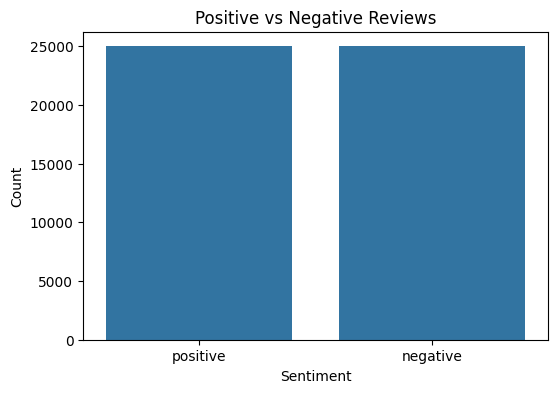

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["sentiment"])
plt.title("Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

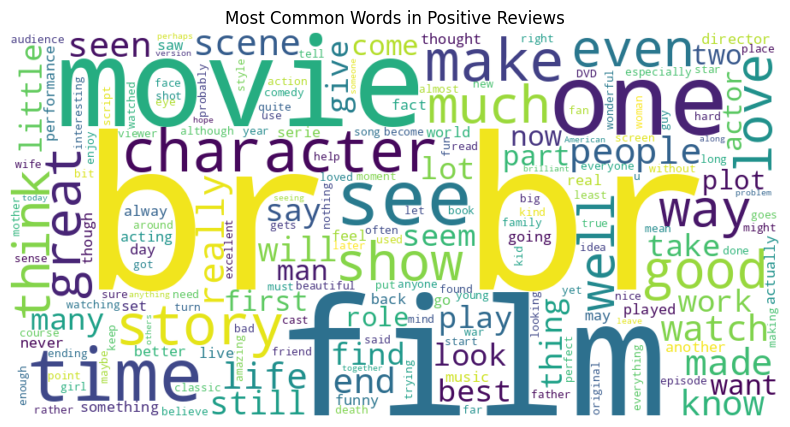

In [6]:
positive_text = " ".join(df[df["sentiment"] == "positive"]["review"].astype(str))

wordcloud = WordCloud(width=900, height=450, background_color="white").generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Positive Reviews")
plt.show()

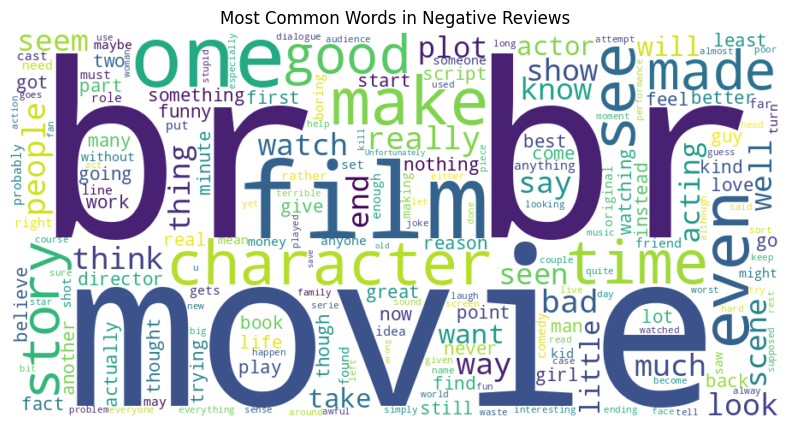

In [7]:
negative_text = " ".join(df[df["sentiment"] == "negative"]["review"].astype(str))

wordcloud = WordCloud(width=900, height=450, background_color="white").generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()

In [8]:
classifier = pipeline(
    "sentiment-analysis",
    model="siebert/sentiment-roberta-large-english"
)

print("High Accuracy RoBERTa Model Loaded Successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


RobertaForSequenceClassification LOAD REPORT from: siebert/sentiment-roberta-large-english
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


High Accuracy RoBERTa Model Loaded Successfully!


In [9]:
sample_df = df.sample(500, random_state=42)

true_labels = []
predicted_labels = []
confidence_scores = []

for review, sentiment in zip(sample_df["review"], sample_df["sentiment"]):
    result = classifier(review[:512])[0]

    predicted = "positive" if result["label"] == "POSITIVE" else "negative"

    true_labels.append(sentiment)
    predicted_labels.append(predicted)
    confidence_scores.append(result["score"] * 100)

accuracy = accuracy_score(true_labels, predicted_labels)

print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels))

Accuracy: 89.4 %

Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.88      0.89       253
    positive       0.88      0.91      0.89       247

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



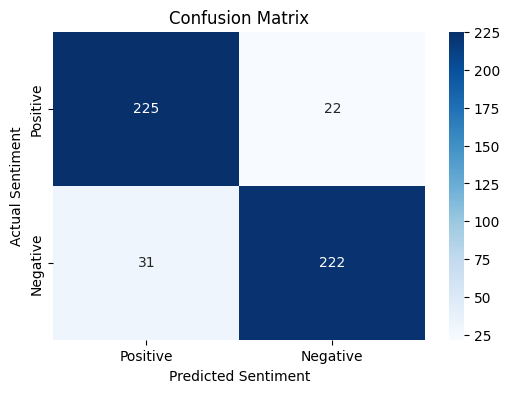

In [10]:
cm = confusion_matrix(true_labels, predicted_labels, labels=["positive", "negative"])

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positive", "Negative"],
    yticklabels=["Positive", "Negative"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

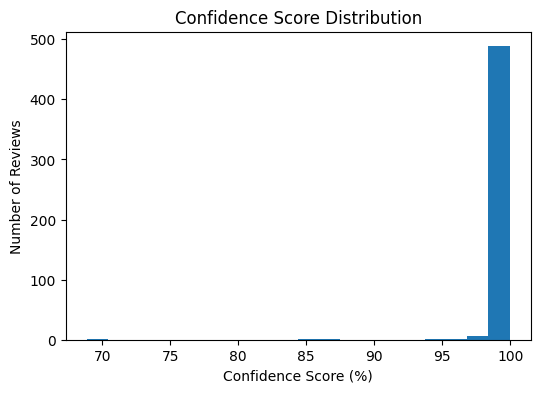

In [11]:
plt.figure(figsize=(6,4))
plt.hist(confidence_scores, bins=20)
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score (%)")
plt.ylabel("Number of Reviews")
plt.show()

In [12]:
sample_results = pd.DataFrame({
    "Actual Sentiment": true_labels[:10],
    "Predicted Sentiment": predicted_labels[:10],
    "Confidence Score (%)": [round(x, 2) for x in confidence_scores[:10]]
})

sample_results

,Actual Sentiment,Predicted Sentiment,Confidence Score (%)
0,positive,negative,99.95
1,positive,positive,99.89
2,negative,negative,99.94
3,positive,positive,99.89
4,negative,negative,99.86
5,positive,positive,99.88
6,positive,positive,99.89
7,positive,positive,99.32
8,negative,negative,99.95
9,negative,negative,99.95


In [13]:
def predict_sentiment(review):
    result = classifier(review[:512])[0]

    sentiment = "Positive Review" if result["label"] == "POSITIVE" else "Negative Review"
    confidence = round(result["score"] * 100, 2)

    return sentiment, str(confidence) + "%"

app = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=6, placeholder="Enter customer review here..."),
    outputs=[
        gr.Textbox(label="Predicted Sentiment"),
        gr.Textbox(label="Confidence Score")
    ],
    title="E-commerce Sentiment Analyzer",
    description="High-accuracy sentiment analysis using Hugging Face RoBERTa Transformer on IMDb 50K reviews."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6871a3a3ec07e78985.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
